# Day-2 : Python Implementation

In [34]:
import os
os.chdir(r'D:\Cynapto Day1')

In [25]:
pip install librosa

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\hp\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [26]:
pip install pyloudnorm

  Using cached pyloudnorm-0.2.0-py3-none-any.whl.metadata (6.6 kB)
Using cached pyloudnorm-0.2.0-py3-none-any.whl (10 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\hp\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
from scipy.signal import resample

## Loading audio
Considering sample.wav for computations

In [45]:
y, sr = librosa.load('sample.wav', sr=None)  # y is the array of no. represg Audio, sr is the sample rate, we use None to keep original sample rate
print(f"Sample rate: {sr} Hz")
print(f"Total samples: {len(y)}")
print(f"Duration: {len(y)/sr:.3f} sec")

Sample rate: 44100 Hz
Total samples: 262094
Duration: 5.943 sec


---
## 1. Sampling Rate & Resampling
Sampling rate is how many times per second the audio signal is captured.

In [48]:
rates = [8000, 16000, 48000]  # 8K, 16K, 48K

for target_sr in rates:
    y_new = librosa.resample(y, orig_sr=sr, target_sr=target_sr)
    sf.write(f'sample_{target_sr}hz.wav', y_new, target_sr)
    print(f"{target_sr} Hz — {len(y_new)} samples")

8000 Hz — 47546 samples
16000 Hz — 95091 samples
48000 Hz — 285273 samples


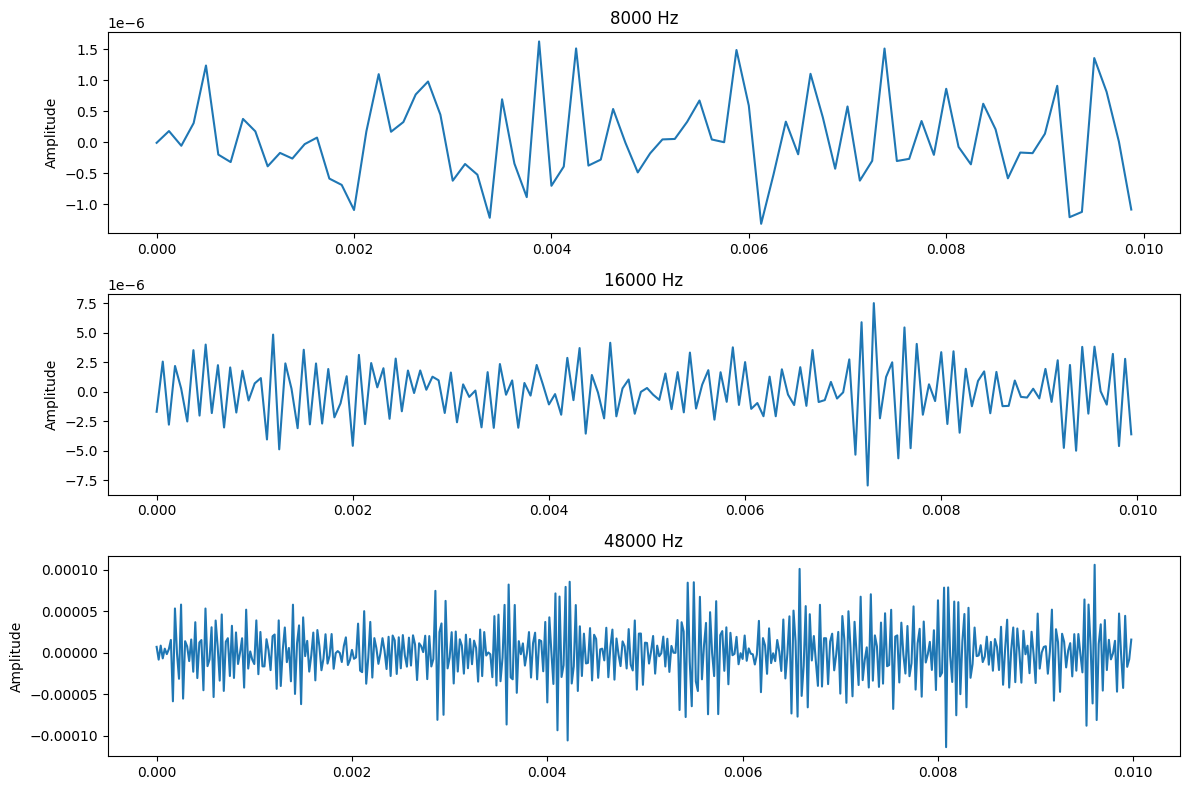

In [54]:
fig, axes = plt.subplots(len(rates), 1, figsize=(12, 8))

for i, target_sr in enumerate(rates):
    y_new = librosa.resample(y, orig_sr=sr, target_sr=target_sr)
    n_samples = int(0.01 * target_sr)  # plotting first 0.01 sec to see the waveform shape
    t = np.arange(n_samples) / target_sr  # time axis
    axes[i].plot(t, y_new[:n_samples])
    axes[i].set_title(f'{target_sr} Hz')
    axes[i].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

---
## 2. Mono vs Stereo
Mono has 1 channel, stereo has 2. For speech processing we use mono.

In [55]:
data, sample_rate = sf.read('sample.wav')

if data.ndim == 1:
    print("This is mono audio")
else:
    print(f"This has {data.shape[1]} channels")

This has 2 channels


---
## 3. Raw Amplitude vs Decibels (dB)
Raw amplitude is linear, dB is logarithmic. dB matches how we actually perceive loudness.

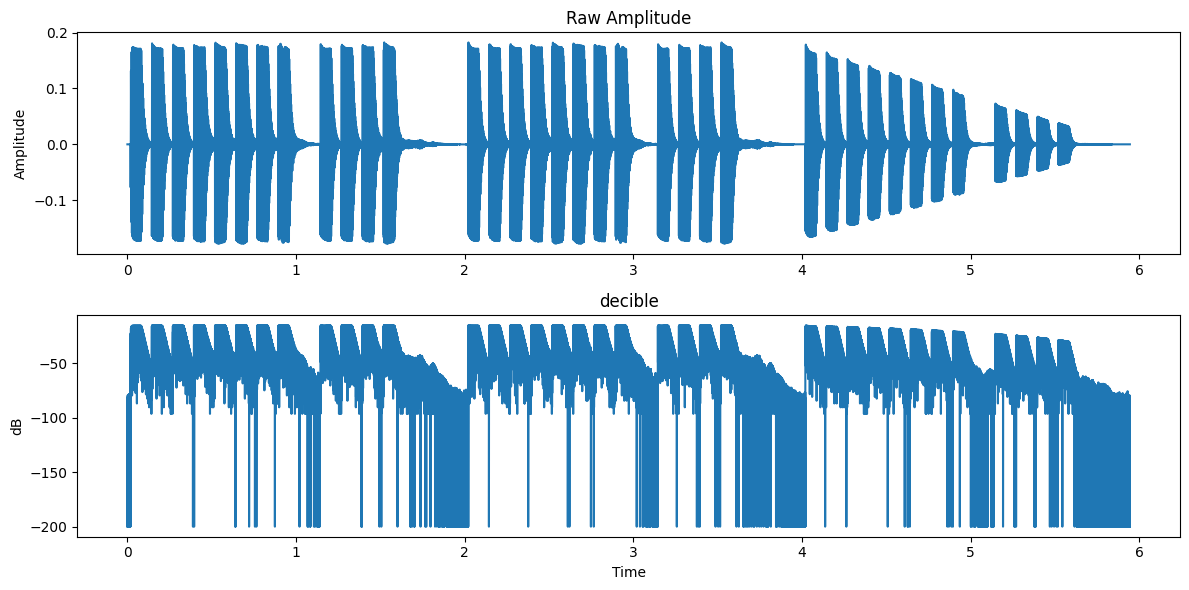

In [59]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

time_axis = np.linspace(0, len(y)/sr, len(y))

ax1.plot(time_axis, y)
ax1.set_title('Raw Amplitude')
ax1.set_ylabel('Amplitude')

# converting to dB
y_db = 20 * np.log10(np.abs(y) + 1e-10)
ax2.plot(time_axis, y_db)
ax2.set_title('decible')
ax2.set_ylabel('dB')
ax2.set_xlabel('Time')

plt.tight_layout()
plt.show()

---
## 4. Frame Size and Hop Size
Frame size = chunk length, hop size = how far we slide the window.

In [60]:
frame_size = 2048
hop_size = 512

print(f"Frame size: {frame_size} samples = {frame_size/sr*1000:.2f} ms")
print(f"Hop size: {hop_size} samples = {hop_size/sr*1000:.1f} ms")
print(f"Overlap: {frame_size - hop_size} samples")

Frame size: 2048 samples = 46.44 ms
Hop size: 512 samples = 11.6 ms
Overlap: 1536 samples


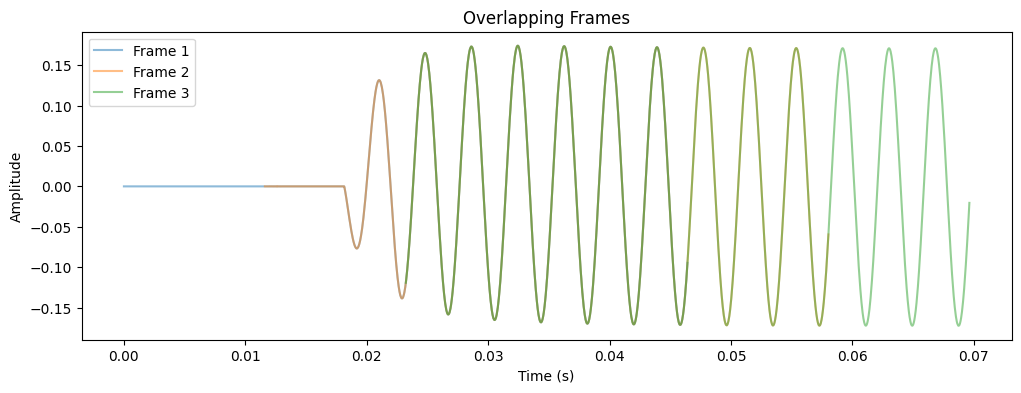

In [63]:
# visualization of Overlapping

plt.figure(figsize=(12, 4))

for i in range(3):
    start = i * hop_size
    end = start + frame_size
    t = np.arange(start, end) / sr
    plt.plot(t, y[start:end], alpha=0.5, label=f'Frame {i+1}')

plt.title('Overlapping Frames')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

---
## 5. STFT (Short-Time Fourier Transform)
Breaks each frame into its frequency components. The result is a spectrogram.

In [65]:
n_fft = 2048  # frame size
hop_length = 512

stft = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
stft_db = librosa.amplitude_to_db(np.abs(stft), ref=np.max)

print(f"STFT shape: {stft.shape}")
print(f"Frequency bins: {stft.shape[0]}, Time frames: {stft.shape[1]}")

STFT shape: (1025, 512)
Frequency bins: 1025, Time frames: 512


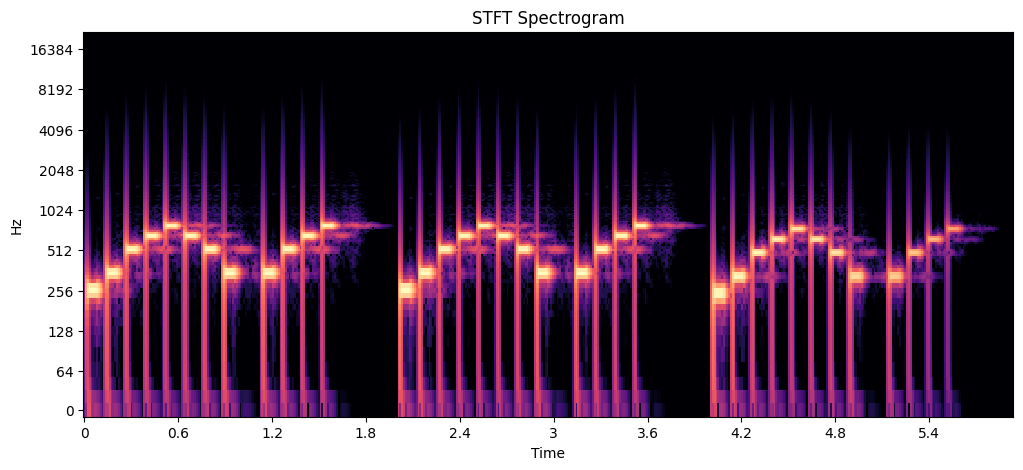

In [69]:
plt.figure(figsize=(12, 5))
librosa.display.specshow(stft_db, sr=sr, hop_length=hop_length,
                         x_axis='time', y_axis='log')

plt.title('STFT Spectrogram')
plt.show()

---
## 6. Mel Spectrogram
Similar to STFT but frequency axis is warped to Mel scale which matches human hearing perception.

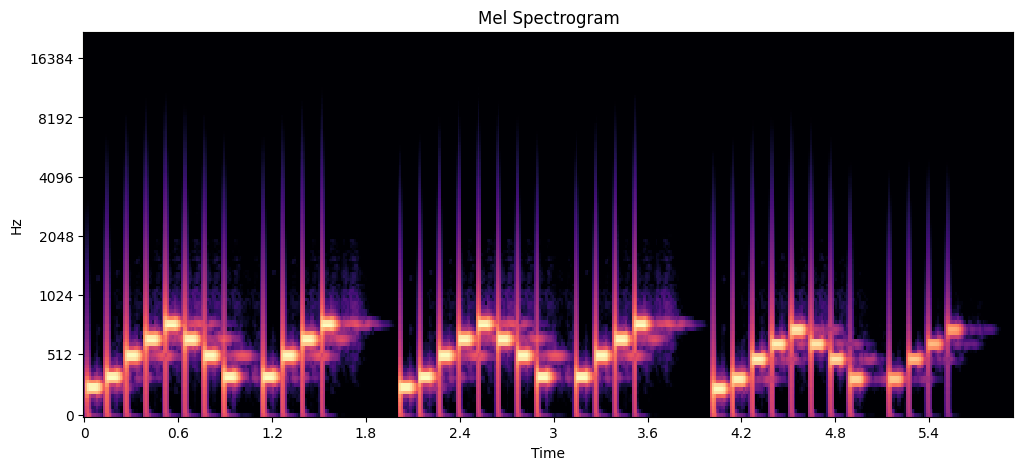

In [73]:
mel_spect = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048,
                                          hop_length=512, n_mels=128)   # applying Mel Filter
mel_spect_db = librosa.power_to_db(mel_spect, ref=np.max)  # Since mel outputs power not Amp

plt.figure(figsize=(12, 5))
librosa.display.specshow(mel_spec_db, sr=sr, hop_length=512,
                         x_axis='time', y_axis='mel')

plt.title('Mel Spectrogram')
plt.show()

---
## 7. RMS Energy
RMS gives the average loudness of each frame. High RMS = loud, low RMS = quiet.

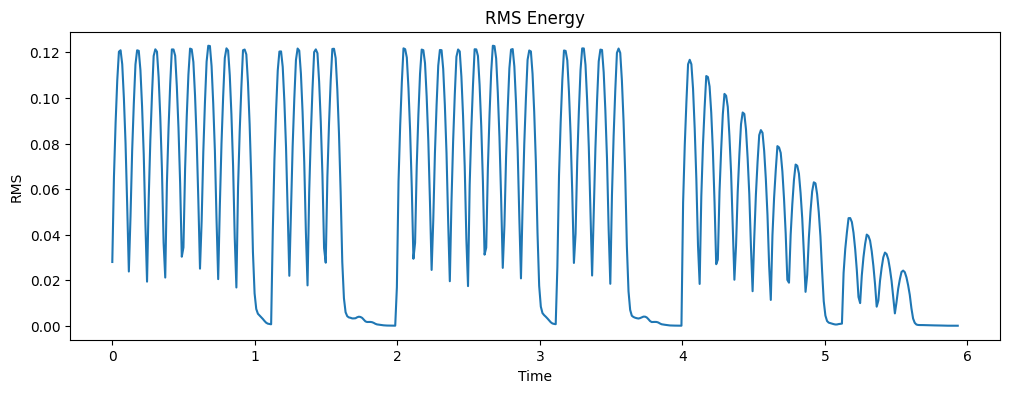

In [78]:
rms = librosa.feature.rms(y=y, frame_length=2048, hop_length=512)[0]
times = librosa.frames_to_time(np.arange(len(rms)), sr=sr, hop_length=512)

plt.figure(figsize=(12, 4))
plt.plot(times, rms)
plt.title('RMS Energy')
plt.xlabel('Time')
plt.ylabel('RMS')
plt.show()

In [79]:
# Manual Computaion of RMS
frames = librosa.util.frame(y, frame_length=2048, hop_length=512)  # framing each column of 2D array
rms_manual = np.sqrt(np.mean(frames**2, axis=0))

print(f"Librosa RMS: {rms[:5]}")
print(f"Manual RMS:  {rms_manual[:5]}")

Librosa RMS: [0.02800604 0.06536739 0.08916684 0.1077561  0.12029361]
Manual RMS:  [0.08916684 0.1077561  0.12029361 0.12091954 0.11481176]


---
## 8. Spectral Flatness
If a frame sounds like noise (close to 1) or a tone (close to 0).

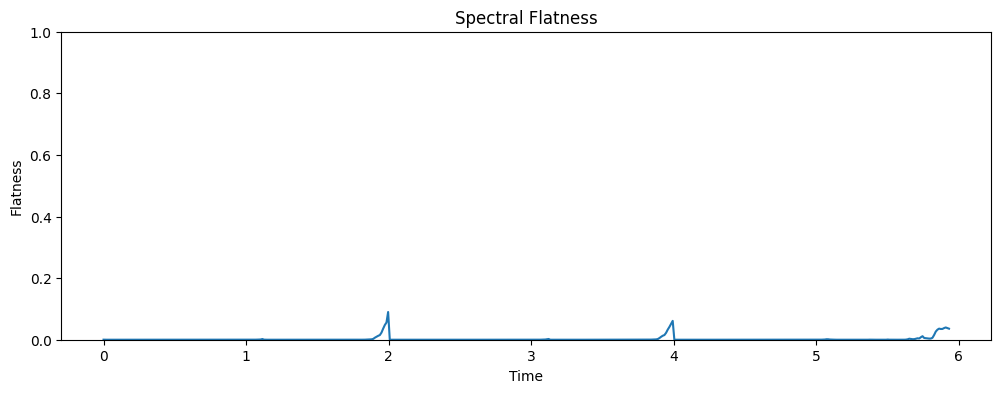

In [80]:
flatness = librosa.feature.spectral_flatness(y=y, n_fft=2048, hop_length=512)[0]
times = librosa.frames_to_time(np.arange(len(flatness)), sr=sr, hop_length=512)

plt.figure(figsize=(12, 4))
plt.plot(times, flatness)
plt.title('Spectral Flatness')
plt.xlabel('Time')
plt.ylabel('Flatness')
plt.ylim(0, 1)
plt.show()

---
## 9. LUFS, True Peak, Sample Peak
LUFS measures perceived loudness. Sample peak is max sample value. True peak accounts for inter-sample peaks.

In [27]:
import pyloudnorm as pyln

meter = pyln.Meter(sr)
loudness = meter.integrated_loudness(y)
print(f"LUFS: {loudness:.2f}")

LUFS: -23.14


In [82]:
#sample Peak
sample_peak = np.max(np.abs(y))
sample_peak_db = 20 * np.log10(sample_peak)
print(f"Sample Peak: {sample_peak:.4f}")

# true peak 
y_upsampled = resample(y, len(y) * 4)
true_peak = np.max(np.abs(y_upsampled))
true_peak_db = 20 * np.log10(true_peak)
print(f"True Peak: {true_peak:.4f}")

Sample Peak: 0.1823
True Peak: 0.1823


---
## 10. Finding Silent Regions
Using RMS energy with a threshold to find where silence is.

In [84]:
frame_length = 2048
hop_length = 512

rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]

threshold = 0.01
is_silent = rms < threshold

silent_regions = []
in_silence = False
start = 0

for i in range(len(is_silent)):
    if is_silent[i] and not in_silence:
        start = i
        in_silence = True
    elif not is_silent[i] and in_silence:
        start_time = librosa.frames_to_time(start, sr=sr, hop_length=hop_length)
        end_time = librosa.frames_to_time(i, sr=sr, hop_length=hop_length)
        if end_time - start_time > 0.2:  # ignoring very short silence duration (200ms)
            silent_regions.append((round(start_time, 2), round(end_time, 2)))
        in_silence = False

print(f"{len(silent_regions)} silent regions:")
for s, e in silent_regions:
    print(f"  {s}s - {e}s (duration: {e-s:.2f}s)")

2 silent regions:
  1.64s - 2.0s (duration: 0.36s)
  3.63s - 4.01s (duration: 0.38s)


---
## 11. RMS Based Volume Matching
Scaling one audio to match another's loudness using their RMS values.

In [88]:
y1, sr1 = librosa.load('sample.wav', sr=None)
y2, sr2 = librosa.load('sample 2.wav', sr=None)

if sr1 != sr2:    # ensuring same sample rate
    y2 = librosa.resample(y2, orig_sr=sr2, target_sr=sr1)
    sr2 = sr1

rms1 = np.sqrt(np.mean(y1**2))
rms2 = np.sqrt(np.mean(y2**2))
print(f"Audio1 RMS: {rms1:.4f}, Audio2 RMS: {rms2:.4f}")

scale = rms1 / rms2
y2_matched = y2 * scale
y2_matched = np.clip(y2_matched, -1.0, 1.0)

rms2_after = np.sqrt(np.mean(y2_matched**2))
print(f"After matching -> Audio1 RMS: {rms1:.4f}, Audio2 RMS: {rms2_after:.4f}")


Audio1 RMS: 0.0712, Audio2 RMS: 0.3813
After matching -> Audio1 RMS: 0.0712, Audio2 RMS: 0.0712


---
## 12. Low vs High Pitch
Pitch is the fundamental frequency (F0) of a voice. Lower F0 = deeper voice, higher F0 = sharper voice.

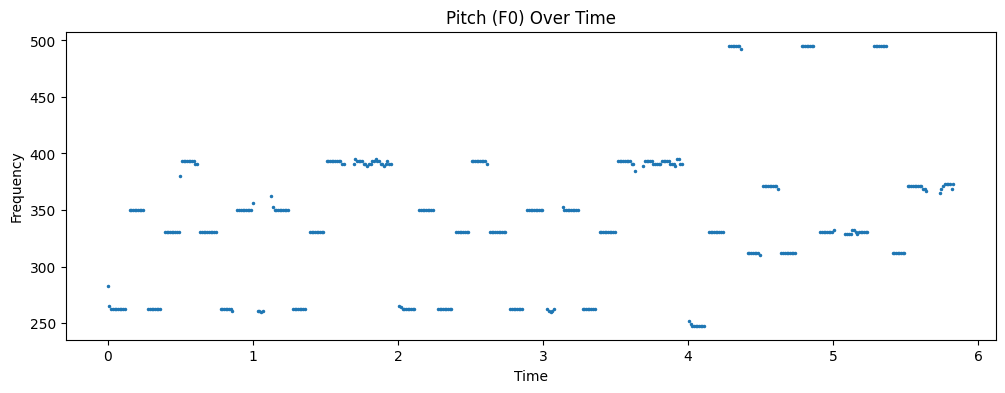

Average pitch: 343.5 Hz
Range: 247.7 - 495.3 Hz


In [94]:
f0, is_voiced, v_prob = librosa.pyin(y, fmin=50, fmax=500,
                                        sr=sr, hop_length=512)
times = librosa.frames_to_time(np.arange(len(f0)), sr=sr, hop_length=512)

plt.figure(figsize=(12, 4))
plt.plot(times, f0, '.', markersize=3)
plt.title('Pitch (F0) Over Time')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()

f0_clean = f0[~np.isnan(f0)]
print(f"Average pitch: {np.mean(f0_clean):.1f} Hz")
print(f"Range: {np.min(f0_clean):.1f} - {np.max(f0_clean):.1f} Hz")